# 03 样条拟合：从离散点到光滑曲线

前面的 notebook 里曲线都是解析给出的（直线、圆、B 样条）。可数控加工的输入是 CAM 排出的**离散刀位点**，必须先把它还原成一条光滑曲线，才能谈弧长、曲率、速度规划。本节走通这条路的每一步。

**本节要回答**

- 离散刀位点如何变成一条光滑样条？
- 参数化（给每个数据点指定参数 $\bar u_i$）为什么重要？均匀、弦长、向心三种参数化差别有多大？
- 插值与最小二乘（least squares）有何区别？分别什么时候用？
- 如何在最小二乘里精确地加上端点位置、切向等约束？
- 单调数据（例如参数同步映射）为什么不能直接用普通三次样条？

**前置知识**：[01](01_曲线与导数栈.ipynb) 的导数栈约定与 B 样条求值。数学约定的细节见 [docs/数学约定.md](../docs/数学约定.md) 第 7 节。

In [1]:
import os.path as osp
import sys
from pathlib import Path

import matplotlib.pyplot as plt

root_path = Path(osp.abspath("")).parents[0]
sys.path.append(str(root_path))

%config InlineBackend.figure_format='retina'

In [2]:
import numpy as np

import cnc5x as cx
from cnc5x import plotting

plotting.use_style()

## 1. 参数化：给每个数据点一个参数值

插值方程 $\mathbf{C}(\bar u_i)=\mathbf{Q}_i$ 里，$\bar u_i$ 是我们自己选的。同样的点列，参数不同，插出来的曲线就不同：

- **均匀参数化**（uniform）：$\bar u_i = i/m$，不管点距；
- **弦长参数化**（chordal）：$\bar u_i$ 与累计弦长成比例，`chord_parameters(Q, exponent=1.0)`；
- **向心参数化**（centripetal）：$\bar u_i$ 与累计 $\sqrt{\text{弦长}}$ 成比例，`exponent=0.5`。

直觉：参数可以想成"时间"。均匀参数化给每一段同样多的时间，长边上曲线只好"冲刺"、短边上"慢走"，速度在长短边交界处突变，曲线就在那里被甩出去。弦长参数化让时间与路程成比例，速度大致均匀。

算例：跑道形的一半——两条长 4 mm 的直边（各取 3 个点，点距 2 mm）接一个半径 1 mm 的半圆（7 个点，点距约 0.52 mm），点距相差约 4 倍。真曲线已知，可以直接量误差。

In [3]:
theta = np.linspace(-np.pi / 2, np.pi / 2, 7)
arc = np.column_stack([4 + np.cos(theta), np.sin(theta)])
Q = np.vstack([[0, -1], [2, -1], arc, [2, 1], [0, 1]])  # 下直边 → 半圆 → 上直边
print("相邻点距：", np.linalg.norm(np.diff(Q, axis=0), axis=1).round(2))

params = {
    "uniform": np.linspace(0, 1, len(Q)),
    "chordal": cx.chord_parameters(Q, 1.0),
    "centripetal": cx.chord_parameters(Q, 0.5),
}
splines = {name: cx.interpolate_bspline(Q, u, 3) for name, u in params.items()}
t = np.linspace(0, 1, 500)  # 后面各节画图用的参数样本

相邻点距： [2.   2.   0.52 0.52 0.52 0.52 0.52 0.52 2.   2.  ]


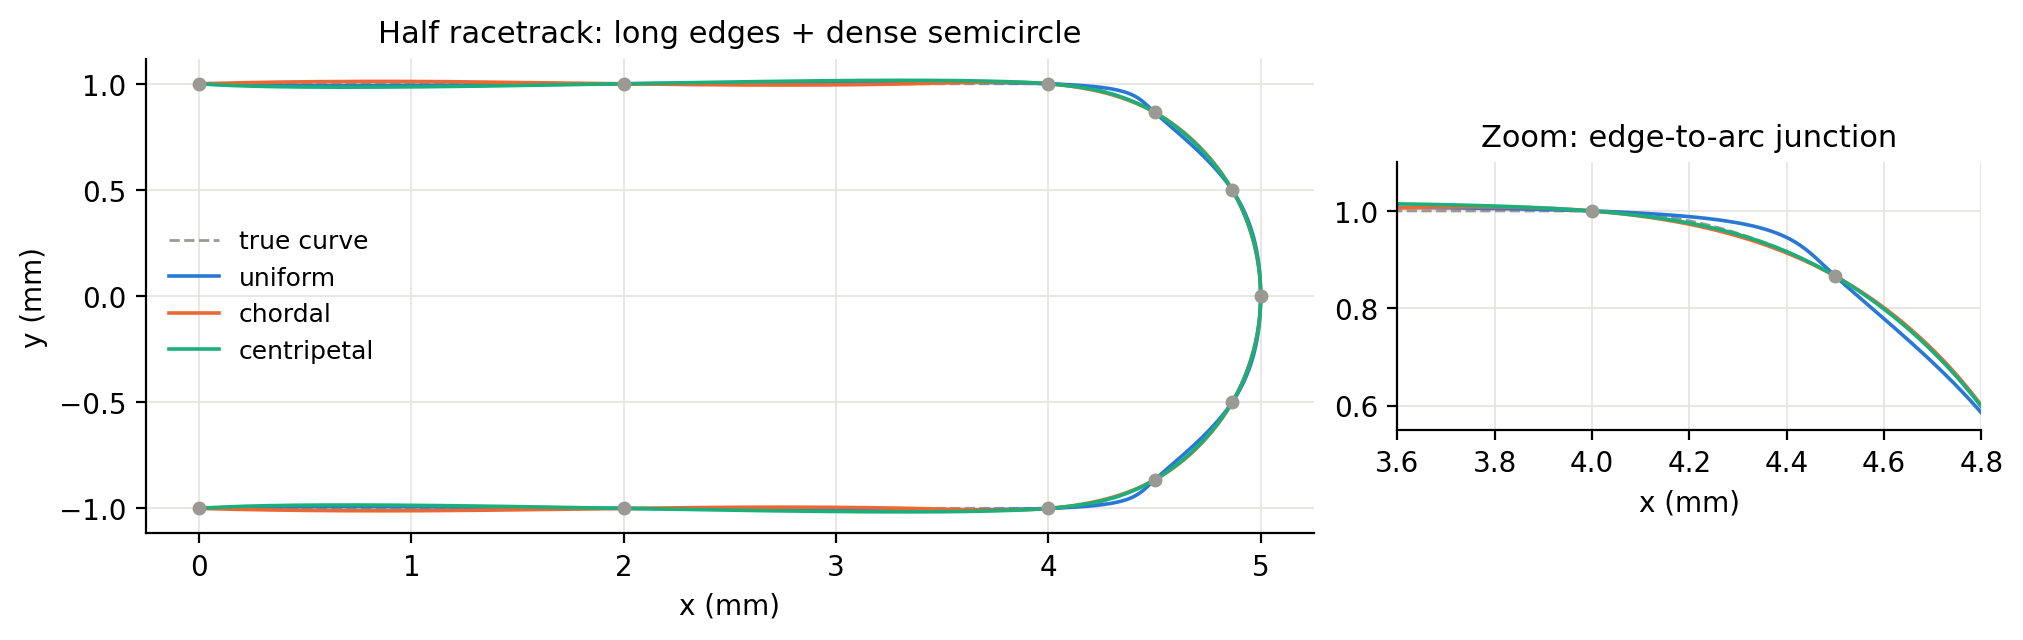

In [4]:
phi = np.linspace(-np.pi / 2, np.pi / 2, 4000)  # 真曲线密集采样（点距约 1e-3 mm），用来量距离
line = np.linspace(0, 4, 4000)
true = np.vstack(
    [
        np.column_stack([line, -np.ones_like(line)]),
        np.column_stack([4 + np.cos(phi), np.sin(phi)]),
        np.column_stack([line[::-1], np.ones_like(line)]),
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), gridspec_kw={"width_ratios": [2, 1]})
for ax in axes:
    ax.plot(*true.T, "--", color=plotting.GRAY, lw=1.0, label="true curve")
    for i, (name, c) in enumerate(splines.items()):
        ax.plot(*c(np.linspace(0, 1, 2000)).T, color=plotting.COLORS[i], label=name)
    ax.plot(*Q.T, "o", color=plotting.GRAY, ms=4)
    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
axes[0].set_ylabel("y (mm)")
axes[0].set_title("Half racetrack: long edges + dense semicircle")
axes[1].set(xlim=(3.6, 4.8), ylim=(0.55, 1.1), title="Zoom: edge-to-arc junction")
axes[0].legend(loc="center left")
plt.show()

放大图里能看到：在"长直边 → 密集圆弧"的交界处，均匀参数化（蓝）沿直边多冲了一段，然后急转弯去追下一个数据点；弦长（橙）与向心（绿）基本贴着真曲线。

位置误差其实都不大（下面打印），真正的差别在**曲率**上。曲率决定拐角限速（第 04 本），所以对插补来说，参数化的好坏首先要看曲率。真曲线的曲率在直边上为 0，在半圆上为 1 mm⁻¹。

uniform      到真曲线的最大距离 0.0271 mm，最大曲率 4.57 1/mm（真值 1）
chordal      到真曲线的最大距离 0.0113 mm，最大曲率 1.17 1/mm（真值 1）
centripetal  到真曲线的最大距离 0.0163 mm，最大曲率 1.20 1/mm（真值 1）


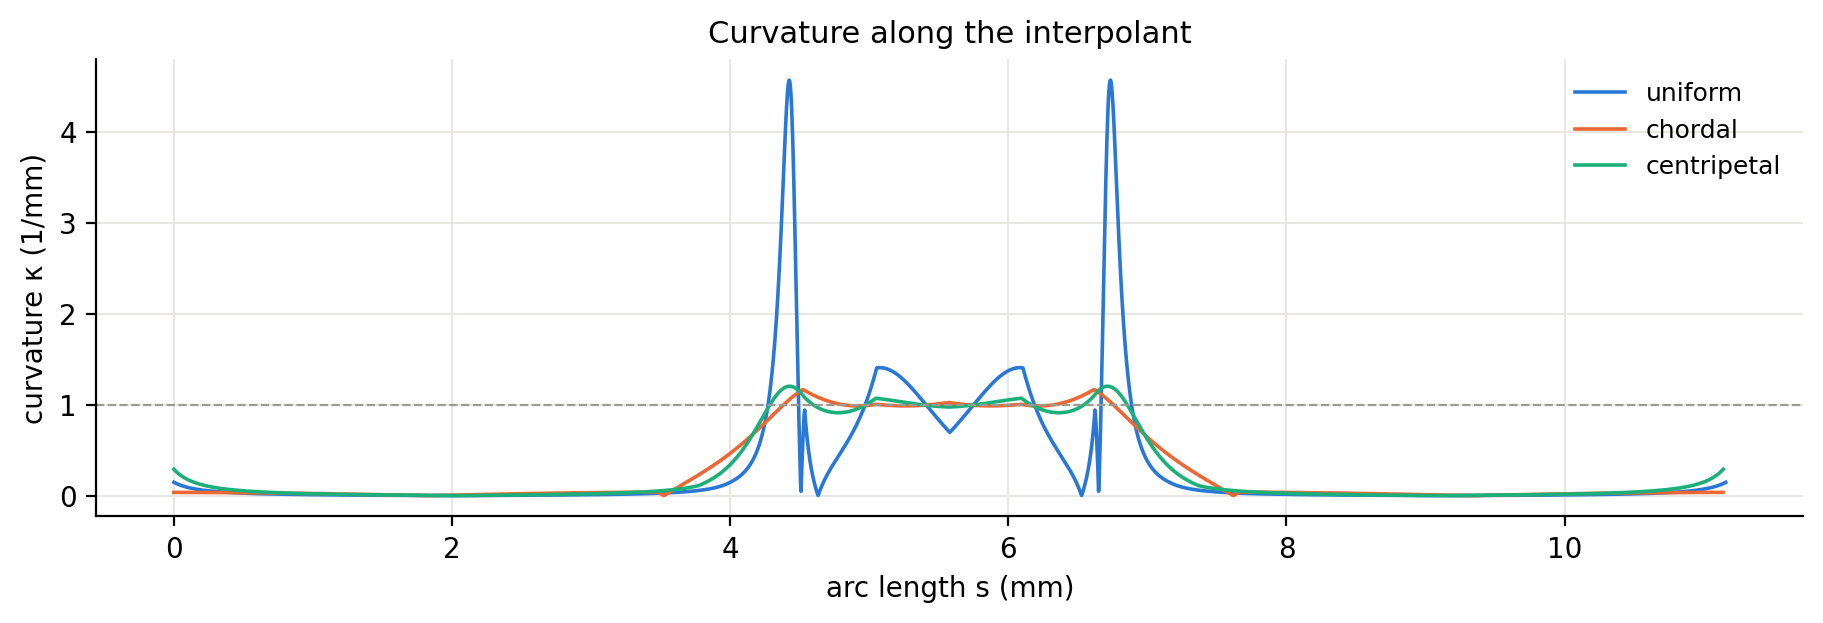

In [5]:
from scipy.spatial import cKDTree

tree = cKDTree(true)
fig, ax = plt.subplots(figsize=(9, 3))
for i, (name, c) in enumerate(splines.items()):
    s = np.linspace(0, c.length, 3000)
    kappa = c.curvature(c.u_at_length(s))
    deviation = tree.query(c(np.linspace(0, 1, 4000)))[0].max()  # 到真曲线（密集采样）的最近距离
    print(f"{name:12s} 到真曲线的最大距离 {deviation:.4f} mm，最大曲率 {kappa.max():.2f} 1/mm（真值 1）")
    ax.plot(s, kappa, color=plotting.COLORS[i], label=name)
ax.axhline(1.0, color=plotting.GRAY, ls="--", lw=0.8)
ax.set(xlabel="arc length s (mm)", ylabel="curvature κ (1/mm)", title="Curvature along the interpolant")
ax.legend()
plt.show()

In [6]:
kappa_max = {name: c.curvature(np.linspace(0, 1, 4001)).max() for name, c in splines.items()}
assert kappa_max["uniform"] > 3 * kappa_max["chordal"]  # 均匀参数化的曲率尖峰是弦长的数倍
assert kappa_max["chordal"] < 1.3  # 弦长参数化的曲率接近真值 1

均匀参数化在交界处的曲率尖峰是真值的四倍多。按法向加速度限速 $v \le \sqrt{A/\kappa}$，曲率大 4.6 倍，这里的速度就要降到约 $1/\sqrt{4.6}\approx 47\%$，而这个急弯是参数化"造"出来的，原始形状里并没有。弦长和向心参数化的曲率都在 1 附近，这个算例上弦长略好一点；换一组点，两者的排名可能反过来。

要点：点距不均时不要用均匀参数化，它会在长短边交界处制造假的曲率尖峰。库里 `pose_spline` 等默认用弦长参数化（`chord_parameters`，exponent=1.0）。

刀轴没有"弦长"，对应的量是球面上的转角：`angle_parameters` 按相邻刀轴的夹角累计参数，第 06 本会用到它。

## 2. 节点与基函数

定好参数后，插值样条的**节点**（knots）取平均节点（The NURBS Book 式 (9.8)）：

$$
u_{j+p} = \frac{\bar u_j + \bar u_{j+1} + \cdots + \bar u_{j+p-1}}{p}, \qquad u_0 = \cdots = u_p = \bar u_0,\ \ u_{n} = \cdots = u_{n+p} = \bar u_m .
$$

`averaged_knots` 实现这个公式。它让每个数据点参数 $\bar u_i$ 大致落在它"影响最强"的节点区间中央（Schoenberg–Whitney 条件），插值矩阵 $\mathbf{N}$ 因此非奇异且数值性质好。

基函数 $N_{j,p}(u)$ 怎么算？按 CLAUDE.md 的分工，求值是数值内核，交给 SciPy：第 $j$ 个基函数就是"第 $j$ 个控制点为 1、其余为 0"的 B 样条，所以把单位矩阵当控制点交给 `scipy.interpolate.BSpline` 求值，一次得到全部基函数——这就是 `basis_matrix`。方程怎么列、怎么解，才是库自己写的部分。

In [7]:
from cnc5x import fitting

u = params["chordal"]
knots = fitting.averaged_knots(u, 3)
print(f"{len(u)} 个数据点 -> {len(knots)} 个节点 -> {len(knots) - 4} 个控制点")
print("节点：", np.round(knots, 3))

11 个数据点 -> 15 个节点 -> 11 个控制点
节点： [0.    0.    0.    0.    0.316 0.407 0.453 0.5   0.547 0.593 0.684 1.
 1.    1.    1.   ]


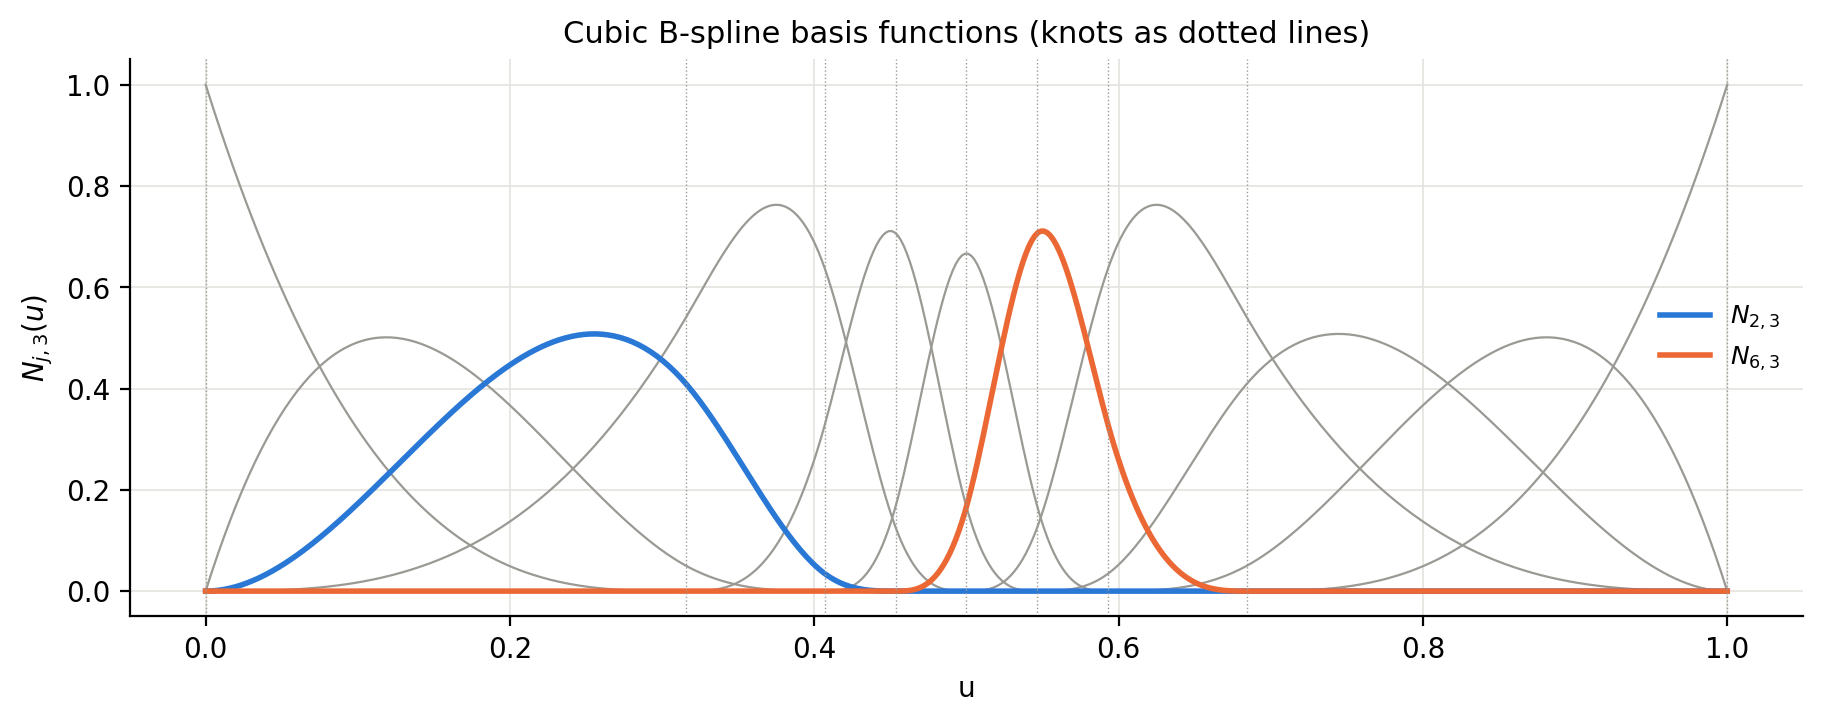

In [8]:
uu = np.linspace(0, 1, 500)
N_all = fitting.basis_matrix(knots, 3, uu)
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(uu, N_all, color=plotting.GRAY, lw=0.8)
for j, c in [(2, plotting.COLORS[0]), (6, plotting.COLORS[1])]:  # 高亮两个基函数
    ax.plot(uu, N_all[:, j], color=c, lw=2, label=f"$N_{{{j},3}}$")
for k in np.unique(knots):
    ax.axvline(k, color=plotting.GRAY, lw=0.5, ls=":")
ax.set(xlabel="u", ylabel="$N_{j,3}(u)$", title="Cubic B-spline basis functions (knots as dotted lines)")
ax.legend()
plt.show()

每个基函数只在 $p+1=4$ 个节点区间上非零（**局部支撑**），且任意参数处全部基函数之和恒等于 1（**单位分解**，partition of unity）——后者保证了曲线对控制点平移不变。检查一下这两个性质。

In [9]:
print("单位分解 max |ΣNⱼ − 1| =", np.abs(N_all.sum(axis=1) - 1).max())
# 局部支撑：在节点区间内部，非零基函数恰好 p+1 个
mid = (knots[5] + knots[6]) / 2
nz = (fitting.basis_matrix(knots, 3, [mid])[0] != 0).nonzero()[0]
print(f"u={mid:.3f} 处非零的基函数下标: {nz}（{len(nz)} 个）")
assert np.abs(N_all.sum(axis=1) - 1).max() < 1e-14 and len(nz) == 4

单位分解 max |ΣNⱼ − 1| = 4.440892098500626e-16
u=0.430 处非零的基函数下标: [2 3 4 5]（4 个）


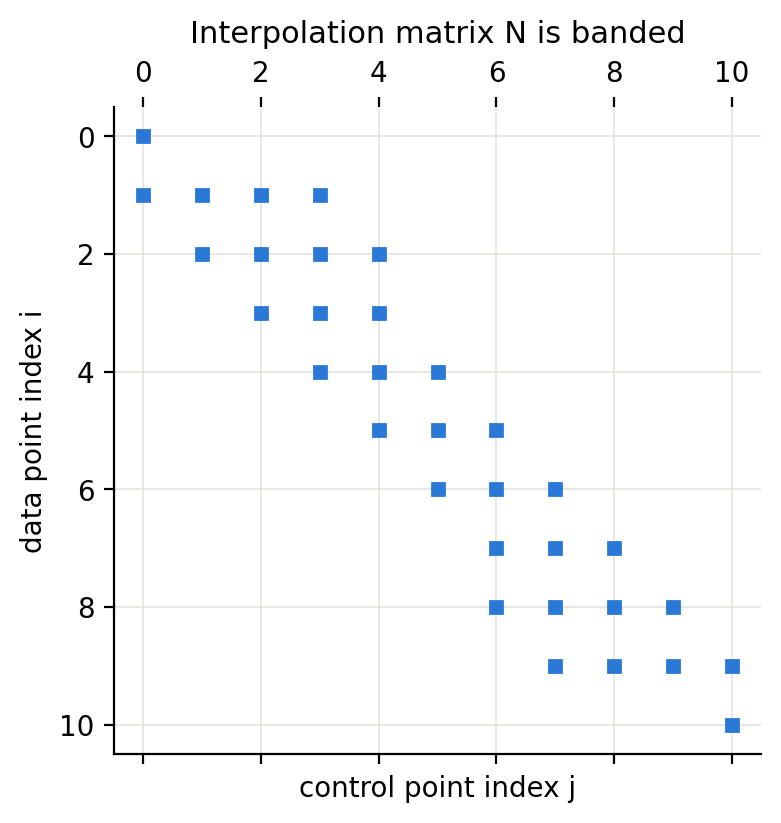

In [10]:
fig, ax = plt.subplots(figsize=(4.5, 4))
N = fitting.basis_matrix(knots, 3, u)
ax.spy(N, markersize=4, color=plotting.COLORS[0])
ax.set(xlabel="control point index j", ylabel="data point index i", title="Interpolation matrix N is banded")
plt.show()

要点：插值矩阵 $\mathbf{N}$ 是**带状**的，每行至多 $p+1$ 个非零元。所以库用稀疏矩阵求解（`scipy.sparse.linalg.spsolve`），几千个刀位点也只要几毫秒。

## 3. 插值：解方程 $\mathbf{N}\mathbf{P}=\mathbf{Q}$

控制点出现在曲线方程 $\mathbf{C}(u)=\sum_j N_{j,p}(u)\mathbf{P}_j$ 里是线性的，所以"过所有数据点"就是一个线性方程组。先用几行 numpy 白盒解一遍，再和库函数 `interpolate_bspline` 对照。

In [11]:
P_whitebox = np.linalg.solve(N, Q)  # 白盒：稠密解 N P = Q
curve = cx.interpolate_bspline(Q, u, 3)
print("白盒解与库的控制点之差：", np.abs(P_whitebox - curve.control_points).max())
res = np.abs(curve(u) - Q).max()
print("数据点处的最大残差：", res)
assert res < 1e-12

白盒解与库的控制点之差： 4.440892098500626e-15
数据点处的最大残差： 8.881784197001252e-16


还可以附加导数条件 $\mathbf{C}^{(k)}(\bar u)=\mathbf{D}$——每加一个条件就多一个控制点，节点向量也要相应加长。典型的用法是指定**端点切向**：没有切向条件时，自由端点的切向完全由附近的点决定，可能朝意料之外的方向偏。

In [12]:
rng = np.random.default_rng(4)
raw = np.cumsum(rng.uniform(-1, 1, (6, 2)), axis=0) * 2
u2 = cx.chord_parameters(raw)
# 6 个点 + 2 个端点切向条件 = 8 个控制点：把 u₀、uₘ 各重复一次再取平均节点
knots2 = fitting.averaged_knots(np.concatenate([[u2[0]], u2, [u2[-1]]]), 3)
D0, D1 = np.array([3.0, 1.0]), np.array([3.0, -1.0])
free = cx.interpolate_bspline(raw, u2, 3)
fixed = cx.interpolate_bspline(raw, u2, 3, knots=knots2, derivatives=[(0.0, 1, D0), (1.0, 1, D1)])
print("两端切向：", fixed(0.0, 1), fixed(1.0, 1))
assert np.abs(fixed(u2) - raw).max() < 1e-12

两端切向： [3. 1.] [ 3. -1.]


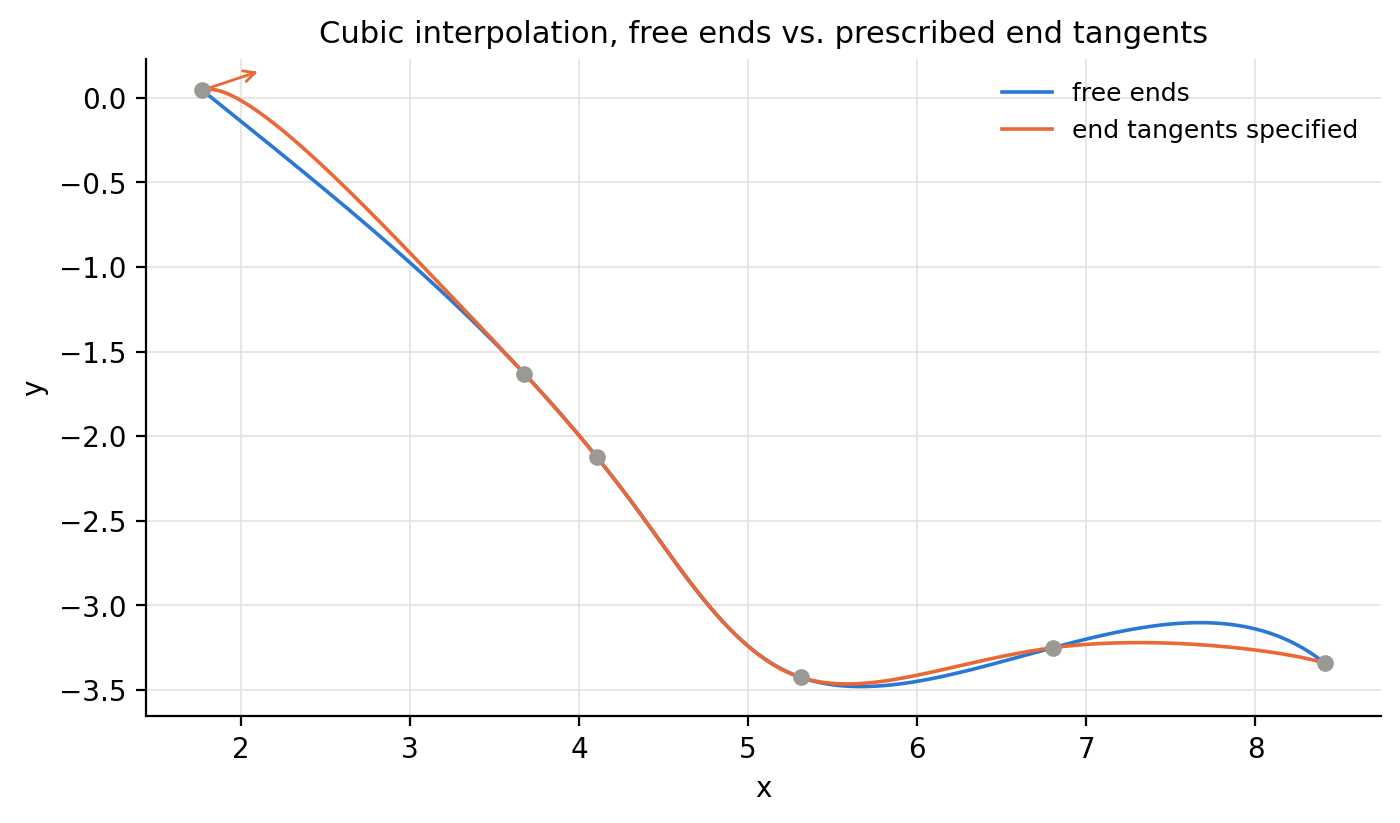

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(*free(t).T, color=plotting.COLORS[0], label="free ends")
ax.plot(*fixed(t).T, color=plotting.COLORS[1], label="end tangents specified")
for p, D, c in [(raw[0], D0, plotting.COLORS[1]), (raw[-1], D1, plotting.COLORS[1])]:
    ax.annotate("", xy=p + 0.12 * D, xytext=p, arrowprops=dict(arrowstyle="->", color=c))
ax.plot(*raw.T, "o", color=plotting.GRAY, ms=5, zorder=3)
ax.set(xlabel="x", ylabel="y", title="Cubic interpolation, free ends vs. prescribed end tangents")
ax.set_aspect("equal")
ax.legend()
plt.show()

要点：插值是"每个点都要精确经过"，方程个数等于未知数个数。适合**没有噪声**的刀位点；导数条件通过在参数端点处（只涉及首尾各两个控制点）加方程来实现。

## 4. 最小二乘逼近：不追求过每个点

数据带噪声时（测量数据、伺服反馈、人为平滑过的点列），插值会把噪声原样传给曲线，控制点比数据点还多没意义。改用**最小二乘**：控制点个数 $n+1$ 少于数据点个数 $m+1$，求

$$
\min_{\mathbf{P}}\ \sum_i w_i\,\lVert \mathbf{C}(\bar u_i) - \mathbf{Q}_i \rVert^2
\quad\Longrightarrow\quad
\mathbf{N}^T\mathbf{W}\mathbf{N}\,\mathbf{P} = \mathbf{N}^T\mathbf{W}\mathbf{Q} .
$$

控制点少了，平均节点不再适用；`approximation_knots` 按 The NURBS Book 式 (9.68)–(9.69) 选节点，保证每个节点区间里都有数据点（否则法方程奇异）。

造一组带噪声的数据：一条斜率变化剧烈、接近单调的曲线（后面第 7 节还会用到它），平台处叠加高斯噪声。

In [14]:
def trim_data(seed, sigma=0.5, m=80):
    rng = np.random.default_rng(seed)
    xi = np.linspace(0, 10, m)
    base = 2 * np.sin(0.9 * xi) + 0.5 * xi
    dy = np.diff(base)
    plat = np.argmax(np.abs(dy) < 0.02)  # 在最平缓处
    base[plat + 1 :] -= dy[plat + 1 :].sum()  # 人为压出一个平台
    return xi, base + sigma * rng.normal(size=m)


xi, yi = trim_data(seed=11)
slope = np.diff(2 * np.sin(0.9 * xi) + 0.5 * xi) / np.diff(xi)[0]
print(f"真值割线斜率范围约 [{slope.min():.2f}, {slope.max():.2f}]，平台在坡度最小处")

真值割线斜率范围约 [-1.30, 2.30]，平台在坡度最小处


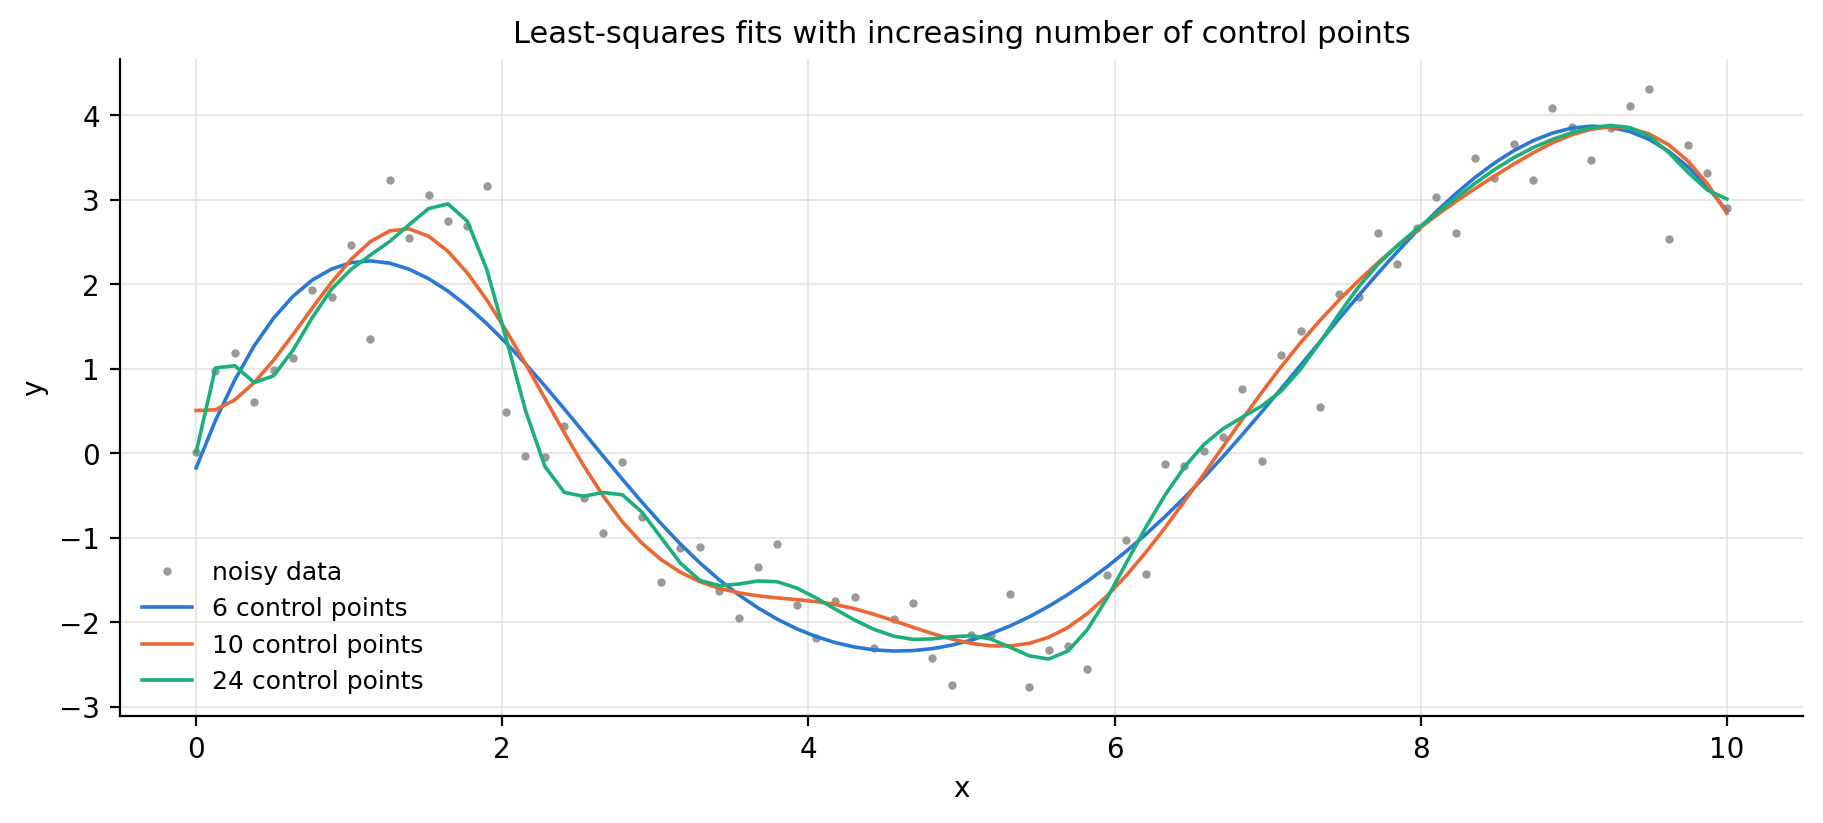

In [15]:
fits = {}
for nc in [6, 10, 24]:
    knots = fitting.approximation_knots(xi, nc, 3)
    fits[nc] = cx.fit_bspline(yi, xi, knots)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xi, yi, ".", color=plotting.GRAY, ms=4, label="noisy data")
for i, (nc, c) in enumerate(fits.items()):
    ax.plot(xi, c(xi)[:, 0], color=plotting.COLORS[i], label=f"{nc} control points")
ax.set(xlabel="x", ylabel="y", title="Least-squares fits with increasing number of control points")
ax.legend()
plt.show()

控制点太少（6 个）拐不过弯来，是**欠拟合**；太多（24 个）开始描噪声的抖动，是**过拟合**。用残差 RMS 对控制点数画图，并检查过拟合的直接证据——拟合曲线出现负斜率（真值单调不减，y 方向不该往回走）。

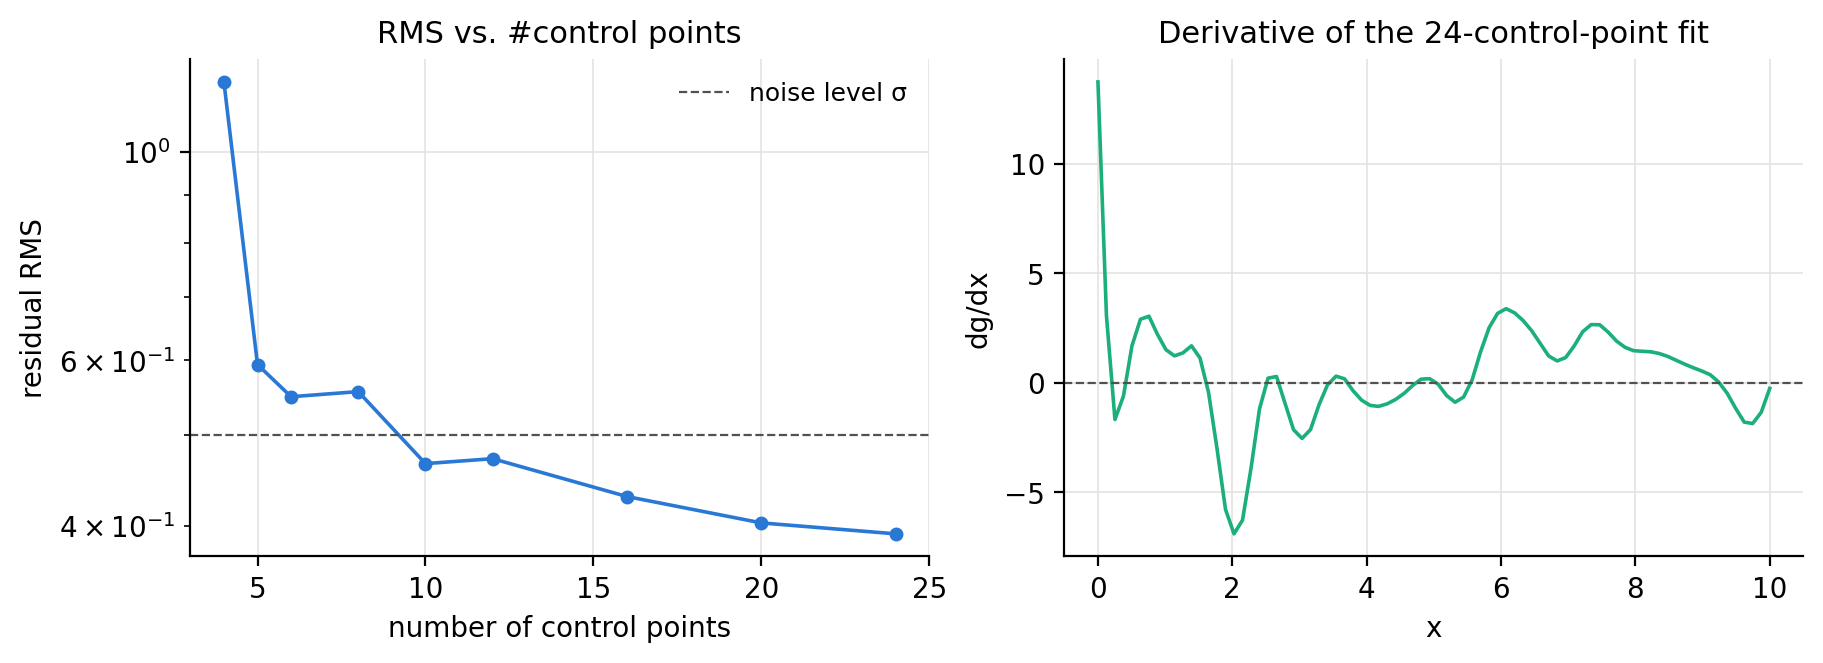

In [16]:
rms = []
ncs = [4, 5, 6, 8, 10, 12, 16, 20, 24]
for nc in ncs:
    c = cx.fit_bspline(yi, xi, fitting.approximation_knots(xi, nc, 3))
    rms.append(np.sqrt(np.mean((c(xi)[:, 0] - yi) ** 2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))
ax1.semilogy(ncs, rms, "o-", color=plotting.COLORS[0])
ax1.axhline(0.5, color=plotting.LIMIT, ls="--", lw=0.8, label="noise level σ")
ax1.set(xlabel="number of control points", ylabel="residual RMS", title="RMS vs. #control points")
ax1.legend()
ax2.plot(xi, fits[24](xi, 1)[:, 0], color=plotting.COLORS[2])
ax2.axhline(0, color=plotting.LIMIT, ls="--", lw=0.8)
ax2.set(xlabel="x", ylabel="dg/dx", title="Derivative of the 24-control-point fit")
plt.show()

In [17]:
print("RMS：", np.round(rms, 3))
print("24 个控制点时最小斜率：", fits[24](np.linspace(0, 10, 2000), 1).min().round(2))

RMS： [1.186 0.594 0.549 0.556 0.466 0.472 0.43  0.403 0.392]
24 个控制点时最小斜率： -6.91


**权重**。噪声方差随位置变化时，给可信的点更大的 $w_i$。注意一个容易踩的坑：SciPy 的 `make_lsq_spline` 把权重乘在**残差**上（目标是 $\sum (w_i r_i)^2$），本库是 $\sum w_i r_i^2$，所以对照时 SciPy 一侧要传 $\sqrt{w_i}$（数学约定第 7 节写明了这个差异）。

In [18]:
from scipy import interpolate as si

rng = np.random.default_rng(3)
w = np.where(xi < 6, 1.0 + 0.05 * rng.normal(size=len(xi)), 0.01)  # 平台段大幅降权
knots10 = fitting.approximation_knots(xi, 10, 3)
ours = cx.fit_bspline(yi, xi, knots10, weights=w)
ref = si.make_lsq_spline(xi, yi, knots10, k=3, w=np.sqrt(w))  # SciPy 传 √w
diff = np.abs(ours(np.linspace(0, 10, 200))[:, 0] - ref(np.linspace(0, 10, 200))).max()
print("与 scipy.make_lsq_spline 的最大差：", diff)
assert diff < 1e-12

与 scipy.make_lsq_spline 的最大差： 6.439293542825908e-15


要点：数据有噪声就用最小二乘，控制点数是唯一的"光滑度旋钮"；RMS 曲线降到噪声水平附近就该停。权重约定和 SciPy 差一个平方根。

## 5. 约束最小二乘：KKT 方程组

光顺的同时，常常要求某些条件**精确**成立——例如首末端点必须精确落在给定位置（下一段刀路从这里接着走）、端点切向必须等于给定方向。这是带等式约束的最小二乘：

$$
\min_{\mathbf{P}}\ \lVert \mathbf{W}^{1/2}(\mathbf{N}\mathbf{P}-\mathbf{Q}) \rVert^2
\quad \text{s.t.}\quad \mathbf{A}\mathbf{P} = \mathbf{b},
$$

其中 $\mathbf{A}$ 的每一行是某个条件 $\mathbf{C}^{(k)}(\bar u)=\mathbf{D}$ 对应的基函数（导数）行。引入 Lagrange 乘子 $\boldsymbol\lambda$，对 $\mathbf{P}$ 和 $\boldsymbol\lambda$ 求偏导并令其为零，得到 KKT 方程组：

$$
\begin{bmatrix}\mathbf{N}^T\mathbf{W}\mathbf{N} & \mathbf{A}^T\\ \mathbf{A} & \mathbf{0}\end{bmatrix}
\begin{bmatrix}\mathbf{P}\\ \boldsymbol\lambda\end{bmatrix}
=
\begin{bmatrix}\mathbf{N}^T\mathbf{W}\mathbf{Q}\\ \mathbf{b}\end{bmatrix}.
$$

它没有把约束混进目标里加权（那样约束只是"近似"成立），而是精确满足。`fit_bspline(..., constraints=[(ū, k, D), ...])` 就是解这个方程组。

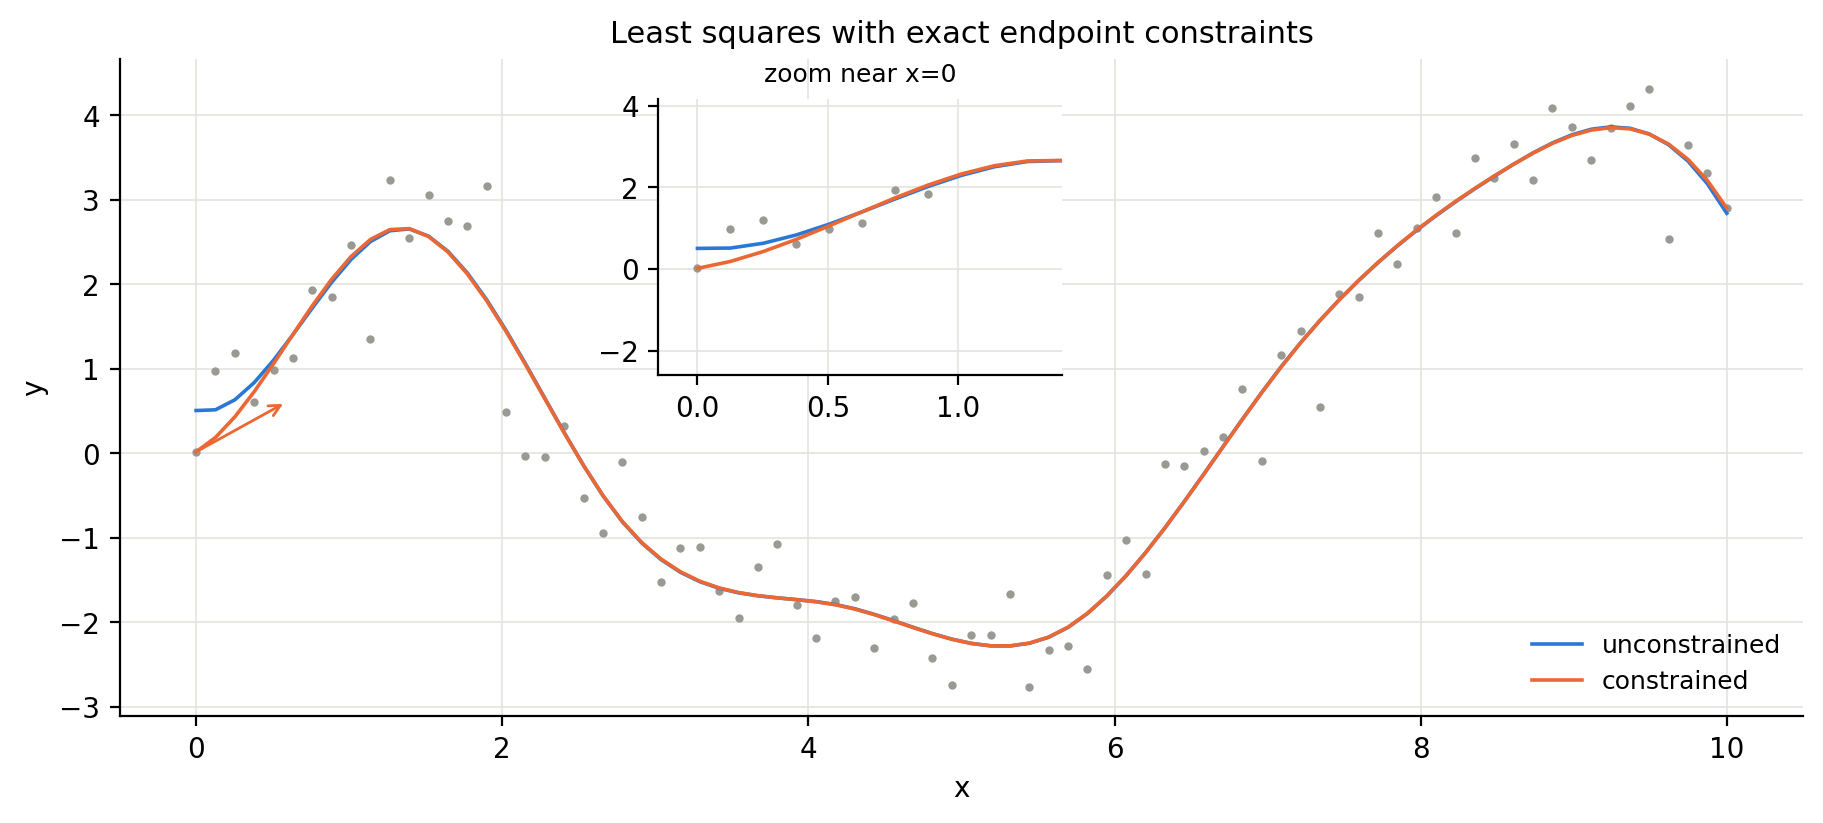

In [19]:
cons = [(xi[0], 0, yi[0]), (xi[-1], 0, yi[-1]), (xi[0], 1, 1.0)]  # 两端点 + 起点斜率
constrained = cx.fit_bspline(yi, xi, knots10, constraints=cons)
unconstrained = cx.fit_bspline(yi, xi, knots10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(xi, yi, ".", color=plotting.GRAY, ms=4)
ax.plot(xi, unconstrained(xi)[:, 0], color=plotting.COLORS[0], label="unconstrained")
ax.plot(xi, constrained(xi)[:, 0], color=plotting.COLORS[1], label="constrained")
ax.annotate("", xy=(0.6, yi[0] + 0.6), xytext=(0, yi[0]), arrowprops=dict(arrowstyle="->", color=plotting.COLORS[1]))
ax.set(xlabel="x", ylabel="y", title="Least squares with exact endpoint constraints")
ax.legend(loc="lower right")
axin = ax.inset_axes([0.32, 0.52, 0.24, 0.42])  # 起点附近放大
axin.plot(xi[:8], yi[:8], ".", color=plotting.GRAY, ms=4)
axin.plot(xi[:120], unconstrained(xi[:120])[:, 0], color=plotting.COLORS[0])
axin.plot(xi[:120], constrained(xi[:120])[:, 0], color=plotting.COLORS[1])
axin.set_xlim(-0.15, 1.4)
axin.set_title("zoom near x=0", fontsize=9)
plt.show()

In [20]:
res = [constrained(xi[0])[0] - yi[0], constrained(xi[-1])[0] - yi[-1], constrained(xi[0], 1)[0] - 1.0]
print("约束残差（端点位置 ×2、起点斜率）：", np.round(res, 15))
print(f"无约束时：起点偏差 {unconstrained(xi[0])[0] - yi[0]:.3f}、起点斜率 {unconstrained(xi[0], 1)[0]:.3f}")
assert np.abs(res).max() < 1e-12

约束残差（端点位置 ×2、起点斜率）： [0. 0. 0.]
无约束时：起点偏差 0.489、起点斜率 -0.428


要点：约束通过 Lagrange 乘子精确满足（残差在 $10^{-16}$ 量级），代价只是方程组多了几行。无约束拟合的起点偏差近 0.5 mm、起点斜率甚至为负，约束把这些都钉住了。

## 6. Hermite 插值与 Bézier 拼接

插值和最小二乘都由**点**出发；另一类构造由**端点导数**出发：给定两端的 0 到 $k$ 阶导数栈，唯一确定一条 $2k+1$ 次多项式（$k=1$ 三次、$k=2$ 五次）。`hermite(start, end)` 直接返回 Bézier 曲线，控制点由端点导数公式逐个解出——Bézier 端点的 $r$ 阶导数只取决于端点附近 $r+1$ 个控制点：

$$
\mathbf{C}^{(r)}(0) = \frac{n!}{(n-r)!}\,\Delta^r \mathbf{b}_0,\qquad
\Delta^r \mathbf{b}_0 = \sum_{i=0}^{r} (-1)^{r-i}\binom{r}{i}\mathbf{b}_i .
$$

$k=2$（五次）时即 $\mathbf{b}_1 = \mathbf{b}_0 + \mathbf{C}'/5$，$\mathbf{b}_2 = 2\mathbf{b}_1 - \mathbf{b}_0 + \mathbf{C}''/20$。五次 Hermite 是拐角光顺（Zhao 2013、Xu 2018）的工作马：两端各 3 个条件，正好和相邻段 $C^2$ 相接。

In [21]:
rng = np.random.default_rng(6)
start, end = rng.normal(size=(3, 2)), rng.normal(size=(3, 2))  # 0..2 阶导数栈
H = cx.hermite(start, end)
print("次数：", H.degree, "（0..2 阶 × 两端 = 6 个条件 -> 五次）")
print("端点导数残差：", np.abs(H.derivatives(0.0)[:3] - start).max(), np.abs(H.derivatives(1.0)[:3] - end).max())
assert np.abs(H.derivatives(0.0)[:3] - start).max() < 1e-12

次数： 5 （0..2 阶 × 两端 = 6 个条件 -> 五次）
端点导数残差： 1.3322676295501878e-15 1.5543122344752192e-15


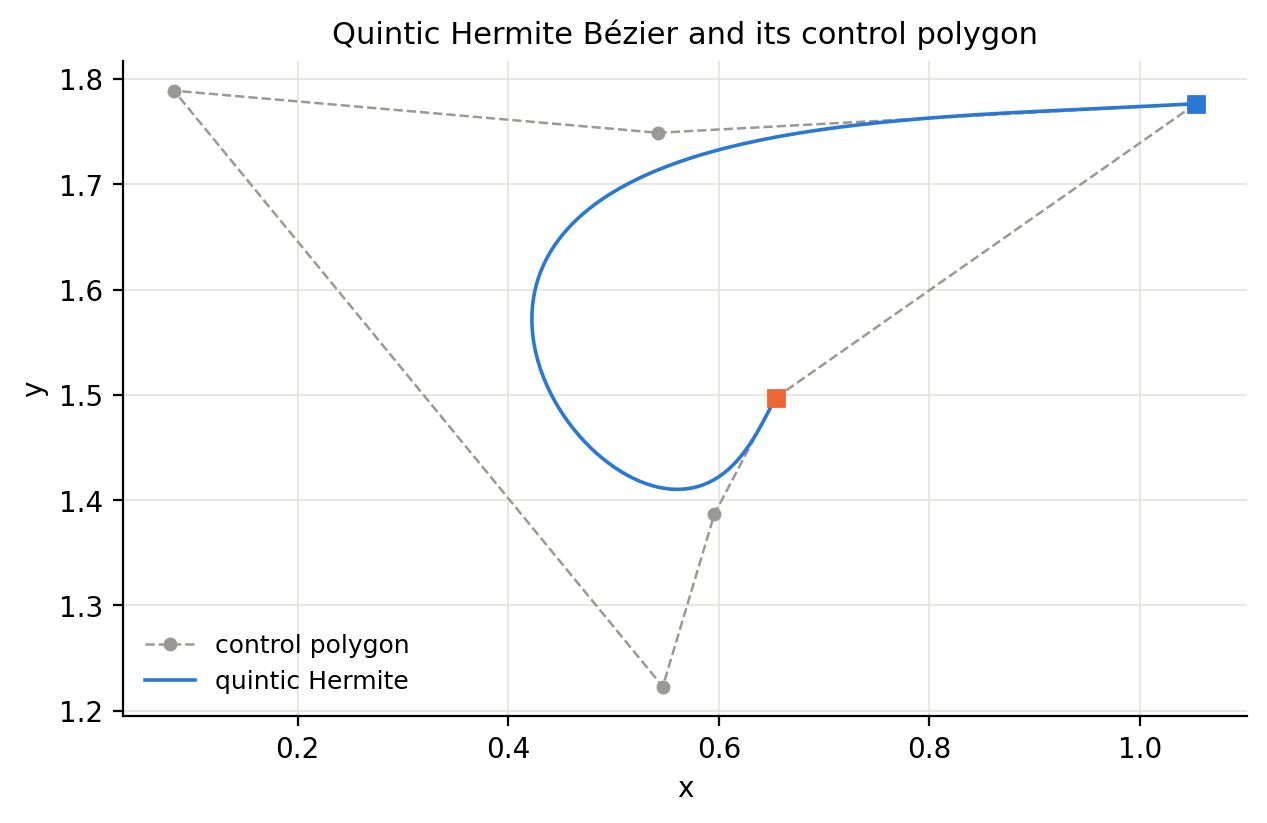

In [22]:
fig, ax = plt.subplots(figsize=(6.5, 4))
b = H.control_points
ax.plot(*np.vstack([b, b[0]]).T, "o--", color=plotting.GRAY, ms=4, lw=0.9, label="control polygon")
ax.plot(*H(np.linspace(0, 1, 200)).T, color=plotting.COLORS[0], label="quintic Hermite")
ax.plot(*start[0], "s", color=plotting.COLORS[0], ms=6)
ax.plot(*end[0], "s", color=plotting.COLORS[1], ms=6)
ax.set(xlabel="x", ylabel="y", title="Quintic Hermite Bézier and its control polygon")
ax.set_aspect("equal")
ax.legend()
plt.show()

把若干段首尾相接的 Bézier 拼成一条 B 样条就是 `join_beziers`：内部节点重数取 $p$，各段控制点原样保留。这种表示本身只保证 $C^0$，更高阶的连续性由各段自己的端点条件保证。

In [23]:
left, right = H.split(0.4)  # de Casteljau 一分为二
joined = fitting.join_beziers([left, right], [0.0, 0.4, 1.0])
diff = np.abs(joined(np.linspace(0, 1, 200)) - H(np.linspace(0, 1, 200))).max()
print("拼接后与原曲线之差：", diff, "；拼接后控制点数：", len(joined.control_points))
assert diff < 1e-12

拼接后与原曲线之差： 1.3322676295501878e-15 ；拼接后控制点数： 11


要点：Hermite 把"端点导数栈"翻译成"Bézier 控制点"，是连接导数世界与样条世界的桥；拼接只是把各段控制点装进一个节点向量，不改动几何。

## 7. 单调插值：保持单调的 $C^2$ 样条

单调数据（例如刀具位置参数 $u$ 到刀轴角度参数 $w$ 的同步映射）用普通三次样条插值会**过冲**：斜率变化剧烈处导数变负，映射不再单调，刀轴会出现"倒转"。`monotone_interpolate(x, y)` 的做法：

1. 节点斜率 $m_k$ 取两侧割线斜率 $\Delta$ 的**调和平均**（Fritsch & Butland 1984，与 SciPy 的 PCHIP 同一思路）；
2. 节点二阶导数取 0，每段用五次 Hermite——所以整条曲线是 $C^2$ 的（PCHIP 只有 $C^1$）；
3. 单调性判据：Bézier 控制点严格递增则曲线严格递增；五次 Hermite 的中间控制点之差含因子 $\Delta - 0.4(m_0+m_1)$，所以要求每段 $m_0 + m_1 \le 2\Delta$，超了就把两端斜率按比例缩小。

造一组带平台的阶梯状数据（斜率相差两个数量级），对比普通插值与单调插值。

In [24]:
xm = np.array([0.0, 0.8, 1.6, 3.0, 3.8, 4.6, 6.4, 7.2, 8.4, 10.0])
ym = np.array([0.0, 0.02, 0.05, 1.8, 2.0, 2.06, 4.5, 4.6, 4.7, 6.0])

g = cx.monotone_interpolate(xm, ym)
ordinary = cx.interpolate_bspline(ym[:, None], xm)  # 对照：普通三次插值
assert np.abs(g(xm)[:, 0] - ym).max() < 1e-12  # 仍精确过每个数据点

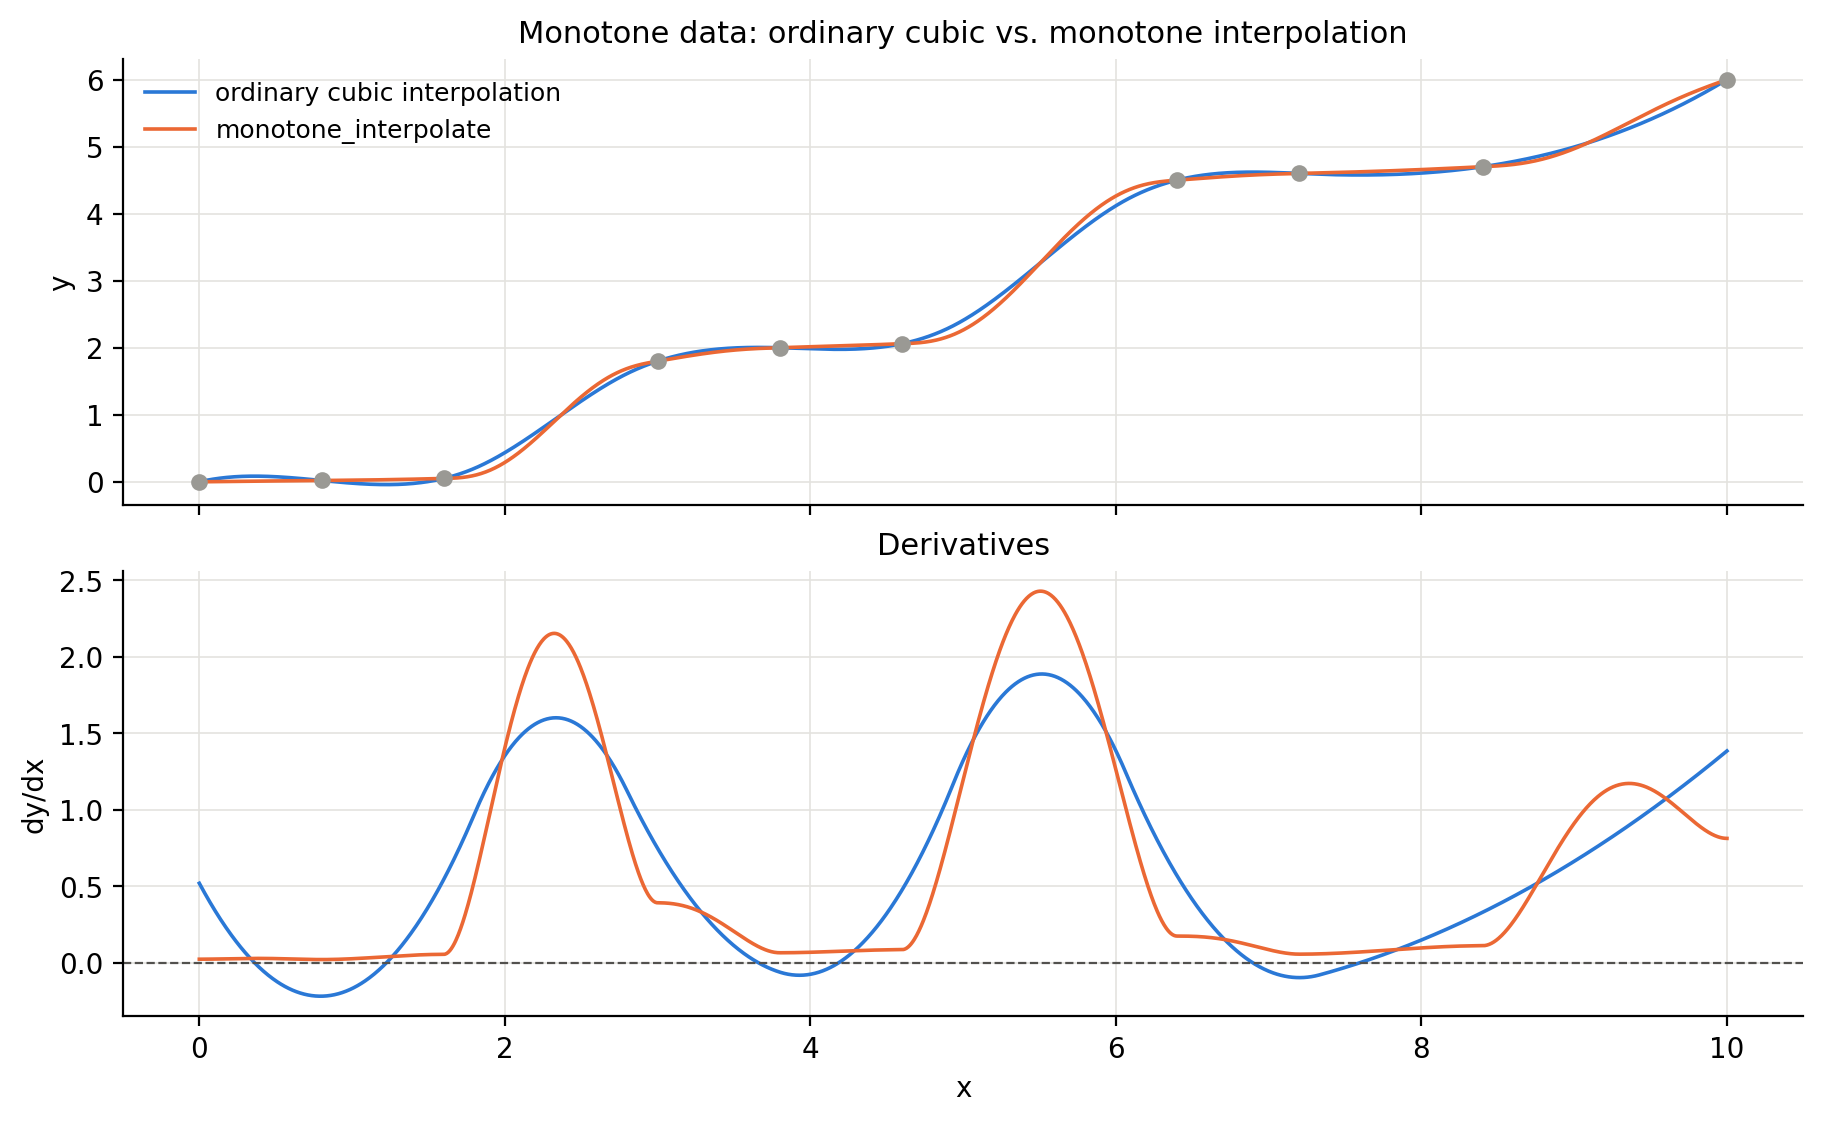

In [25]:
tt = np.linspace(xm[0], xm[-1], 2001)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
ax1.plot(tt, ordinary(tt)[:, 0], color=plotting.COLORS[0], label="ordinary cubic interpolation")
ax1.plot(tt, g(tt)[:, 0], color=plotting.COLORS[1], label="monotone_interpolate")
ax1.plot(xm, ym, "o", color=plotting.GRAY, ms=5, zorder=3)
ax1.set(ylabel="y", title="Monotone data: ordinary cubic vs. monotone interpolation")
ax1.legend()
ax2.plot(tt, ordinary(tt, 1)[:, 0], color=plotting.COLORS[0])
ax2.plot(tt, g(tt, 1)[:, 0], color=plotting.COLORS[1])
ax2.axhline(0, color=plotting.LIMIT, ls="--", lw=0.8)
ax2.set(xlabel="x", ylabel="dy/dx", title="Derivatives")
plt.show()

In [26]:
print("普通插值最小导数：", ordinary(tt, 1).min().round(3), "（< 0，不单调）")
print("单调插值最小导数：", g(tt, 1).min().round(4), "（> 0，严格递增）")
# C² 检查：内部节点两侧二阶导数之差（有跳变时是 O(1) 量级）
h = 1e-7
jump = np.abs(g(xm[1:-1] - h, 2)[:, 0] - g(xm[1:-1] + h, 2)[:, 0]).max()
print("节点处二阶导数两侧之差：", jump)
assert g(tt, 1).min() > 0 and jump < 1e-4

普通插值最小导数： -0.219 （< 0，不单调）
单调插值最小导数： 0.0204 （> 0，严格递增）
节点处二阶导数两侧之差： 3.2148483346268987e-06


要点：对"必须单调"的映射（$u \mapsto w$ 的参数同步）用 `monotone_interpolate`；它精确过每个数据点、$C^2$、严格递增。普通插值样条在这类数据上的过冲不是 bug，是三次样条的本性。

## 练习

1. 把第 1 节的采样角从 `[25, 33, 44, 52, 58, 62, 75, 90, 105, 120, 134]` 改成更稀疏的版本（把后 5 点都删掉，只保留前半段 6 点），再比较三种参数化：均匀参数化的凸包会大多少？弦长还会贴近真圆吗？
2. 第 4 节中把控制点数扫到 `ncs` 上限 40、60，观察 RMS 与拟合曲线：RMS 还在降吗？过拟合的抖动出现在哪里？
3. 第 5 节只保留两个端点位置约束（去掉斜率约束），起点的实际斜率是多少？再加一个终点斜率约束呢？
4. 第 7 节给单调数据再加一段几乎水平的平台（例如 `ym` 插入一对相差 1e-3 的相邻值），验证 `monotone_interpolate` 仍严格递增；普通插值的过冲会恶化多少？

## 延伸阅读

- [docs/数学约定.md](../docs/数学约定.md) 第 7 节：拟合的三种方程组、与 SciPy 权重约定的差异；第 2 节：弧长与弧长表（第 02 本）。
- 刀轴的球面样条 `spherical_spline`（在 $\theta,\varphi$ 球坐标里插值再映回球面）与参数同步 `monotone_interpolate(u, w)` 的组合，见第 06 本 notebook 与 `toolpath.pose_spline`。
- 进给修正多项式 `feed_correction`（Erkorkmaz & Altintas 2001；Yuen et al. 2013）用本节的分段约束最小二乘逼近弧长反函数，见第 [02](02_弧长表与进给波动.ipynb) 本第 7 节。
- 局部拐角光顺中的五次 Hermite 应用：`papers/Zhao2013/`、`papers/Xu2018/`；未实现的想法见 [docs/路线图.md](../docs/路线图.md)。